In [7]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['font.size'] = 10

def custom_month_year_formatter(x, pos):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%Y')
    else:
        return date.strftime('%b')
        
FREQUENCY_THRESHOLD = 0.001
MAX_CLINICAL_DETECTIONS = 0

In [8]:
quality_scores = pd.read_csv('../data/filtered_bam_avg_quality.tsv', sep='\t')
quality_scores['sample'] = quality_scores['file'].str.split('.trimmed').str[0]
# convert Q score to error rate
quality_scores['error_rate'] = 10 ** (-quality_scores['avg_base_quality'] / 10)

coverage_depth = pd.read_csv('../fig2/median_coverage_summary.tsv', sep='\t')
coverage_depth['sample'] = coverage_depth['sample'].str.split('.trimmed').str[0]

sample_metadata = pd.read_csv('../data/search_metadata.csv')

# Join the dataframes on the sample column
quality_scores = quality_scores.merge(coverage_depth, on='sample', how='left')
quality_scores = quality_scores.merge(sample_metadata, on='sample', how='left')


# Group by week, and average the quality scores and coverage depth
quality_scores['week'] = pd.to_datetime(quality_scores['collection_date']).dt.to_period('W').dt.to_timestamp()
quality_scores = quality_scores.groupby('week').agg({'error_rate': 'mean', 'avg_base_quality': 'mean', 'MedianCoverage': 'mean'})

# Load cryptics data
cryptic_snp_freqs = pd.read_csv('../snp_frequencies/cryptic_snp_freqs.csv', index_col='week')
cryptic_snp_freqs.index = pd.to_datetime(cryptic_snp_freqs.index)
cryptic_snp_freqs['cryptic_counts'] = cryptic_snp_freqs.sum(axis=1)

# covar = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
# covar = covar[covar['num_clinical_detections'] <= 0]
# covar['collection_date'] = pd.to_datetime(covar['collection_date'])
# covar['collection_date'] = pd.to_datetime(covar['collection_date'])
# covar['len_mutations'] = covar['nt_mutations'].apply(lambda x:len(x.split(' ')))
# covar = covar[covar['len_mutations'] > 1]
# covar_counts = covar.groupby('nt_mutations').size().reset_index(name='counts')
# covar = covar.merge(covar_counts, on='nt_mutations', how='left')
# covar = covar[covar['counts'] > 1]
# # Count cryptic variant clusters by week
# covar['week'] = covar['collection_date'].dt.to_period('W').dt.to_timestamp()
# cryptic_counts = covar.groupby('week').size().reset_index(name='cryptic_counts')


# # join quality scores and cryptic snp freqs (reset_index so 'week' is a column for merge)
# df = quality_scores.reset_index().merge(cryptic_counts.reset_index(), on='week', how='left')
df = quality_scores.reset_index().merge(cryptic_snp_freqs.reset_index(), on='week', how='left')

df['platform'] = df['week'].apply(lambda x: 'Ion Torrent' if x <= pd.to_datetime("2024-03-01") else "NextSeq")

print(df)

          week  error_rate  avg_base_quality  MedianCoverage    A>T    A>C  \
0   2022-12-26    0.006310         22.000000    10763.000000   10.0    5.0   
1   2023-01-02    0.005621         22.525000     8396.625000   95.0   45.0   
2   2023-01-09    0.005363         22.733333     7821.388889   77.0   41.0   
3   2023-01-16    0.005679         22.475000     6536.250000   81.0   37.0   
4   2023-01-23    0.005012         23.000000    11290.944444  201.0  127.0   
..         ...         ...               ...             ...    ...    ...   
100 2024-11-25    0.000182         37.400000      949.875000    0.0    1.0   
101 2024-12-02    0.000174         37.587500      380.750000    1.0    2.0   
102 2024-12-09    0.000171         37.671429      584.571429    0.0    2.0   
103 2024-12-23    0.000129         38.900000      484.000000    0.0    0.0   
104 2024-12-30    0.000126         39.000000      871.000000    2.0    0.0   

        A>G    T>A     T>C    T>G    C>A    C>T   C>G    G>A   

In [9]:
# Fit depth + Q score to number of cryptics to get a scaling factor, use that to normalize cryptic counts over time
import numpy as np
from sklearn.linear_model import LinearRegression

# Drop rows with missing values for the fit
df_fit = df.dropna(subset=['cryptic_counts', 'MedianCoverage', 'error_rate']).copy()

# Fit: cryptic count ~ depth + quality
X = np.column_stack([
    np.log1p(df_fit['MedianCoverage']),
    df_fit['error_rate']
])
y = np.log1p(df_fit['cryptic_counts'])

model = LinearRegression().fit(X, y)
df_fit['predicted'] = np.expm1(model.predict(X))

# Scaling factor: predicted relative to median (baseline detection capacity)
median_predicted = df_fit['predicted'].median()
df_fit['scaling_factor'] = df_fit['predicted'] / median_predicted

# Normalized cryptic count: removes technical variation from depth/quality
df_fit['cryptic_counts_normalized'] = df_fit['cryptic_counts'] / df_fit['scaling_factor']

# Summary
print(f"Coefficients: log(depth)={model.coef_[0]:.4f}, quality={model.coef_[1]:.4f}, intercept={model.intercept_:.4f}")
print(f"R² = {model.score(X, y):.4f}")


Coefficients: log(depth)=1.0036, quality=277.4289, intercept=-2.6693
R² = 0.8485


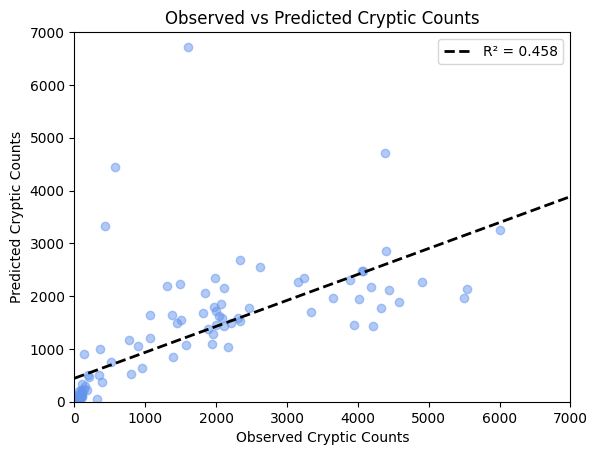

In [10]:
# Plot Observed vs Expected Cryptic Counts
x = df_fit['cryptic_counts'].values
y = df_fit['predicted'].values
plt.scatter(x, y, alpha=0.5, c='cornflowerblue')
coefs = np.polyfit(x, y, 1)
y_pred = np.polyval(coefs, x)
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
x_line = np.linspace(0, 7000, 100)
plt.plot(x_line, np.polyval(coefs, x_line), '--', lw=2, label=f'R² = {r2:.3f}', c='black')
plt.xlabel('Observed Cryptic Counts')
plt.ylabel('Predicted Cryptic Counts')
plt.title('Observed vs Predicted Cryptic Counts')
plt.xlim(0, 7000)
plt.ylim(0, 7000)
plt.legend()
plt.savefig('plots/cryptic_counts_vs_predicted.pdf', transparent=True, bbox_inches='tight', dpi=300)
plt.show()


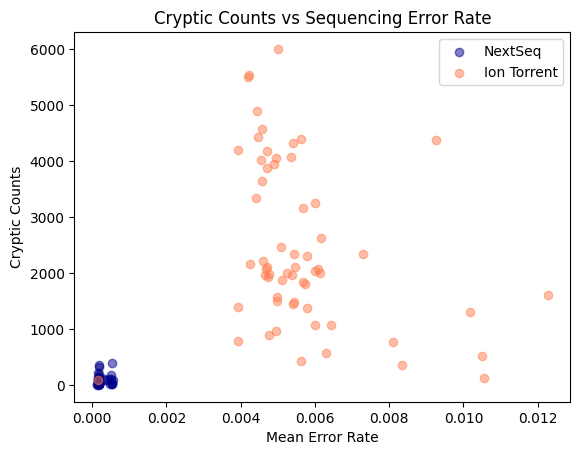

In [11]:
# Plot correlation between cryptic counts and quality scores as a scatter plot
for platform, color in [('NextSeq', 'darkblue'), ('Ion Torrent', 'coral')]:
    mask = df_fit['platform'] == platform
    plt.scatter(df_fit.loc[mask, 'error_rate'], df_fit.loc[mask, 'cryptic_counts'],
               alpha=0.5, c=color, label=platform)
plt.xlabel('Mean Error Rate')
plt.ylabel('Cryptic Counts')
plt.title('Cryptic Counts vs Sequencing Error Rate')
plt.legend()
plt.savefig('plots/cryptic_counts_vs_error_rate.pdf', transparent=True, bbox_inches='tight', dpi=300)
plt.show()


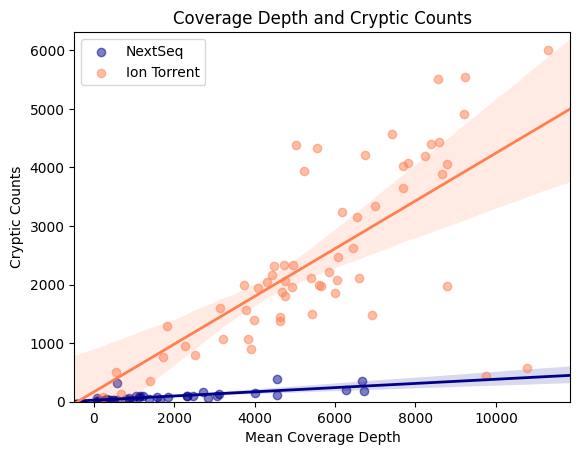

In [12]:
# Plot correlation between cryptic counts and coverage depth
# Separate regression lines per platform with 95% confidence intervals
fig, ax = plt.subplots()
x_min, x_max = df_fit['MedianCoverage'].min(), df_fit['MedianCoverage'].max()
y_min, y_max = df_fit['cryptic_counts'].min(), df_fit['cryptic_counts'].max()
ax.set_xlim(x_min - 0.05 * (x_max - x_min), x_max + 0.05 * (x_max - x_min))
ax.set_ylim(max(0, y_min - 0.05 * (y_max - y_min)), y_max + 0.05 * (y_max - y_min))
for platform, color in [('NextSeq', 'darkblue'), ('Ion Torrent', 'coral')]:
    mask = df_fit['platform'] == platform
    sns.regplot(x='MedianCoverage', y='cryptic_counts', data=df_fit[mask], ax=ax,
                scatter_kws={'alpha': 0.5, 'color': color},
                line_kws={'color': color, 'linewidth': 2},
                ci=95, label=platform, truncate=False)
ax.set_xlabel('Mean Coverage Depth')
ax.set_ylabel('Cryptic Counts')
ax.set_title('Coverage Depth and Cryptic Counts')
ax.legend()
plt.savefig('plots/cryptic_counts_vs_coverage_depth.pdf', transparent=True, bbox_inches='tight', dpi=300)
plt.show()
